# Understanding the given data

In [3]:
import pandas as pd

train = pd.read_csv("train.csv") #77299*11
test = pd.read_csv("test.csv") #41778*10

Missing Values:
Index               0
geohash             0
day                 0
timestamp           0
demand              0
RoadType          600
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      2495
Weather           797
dtype: int64

Duplicate Rows:
0

Number of Unique Locations:
1249


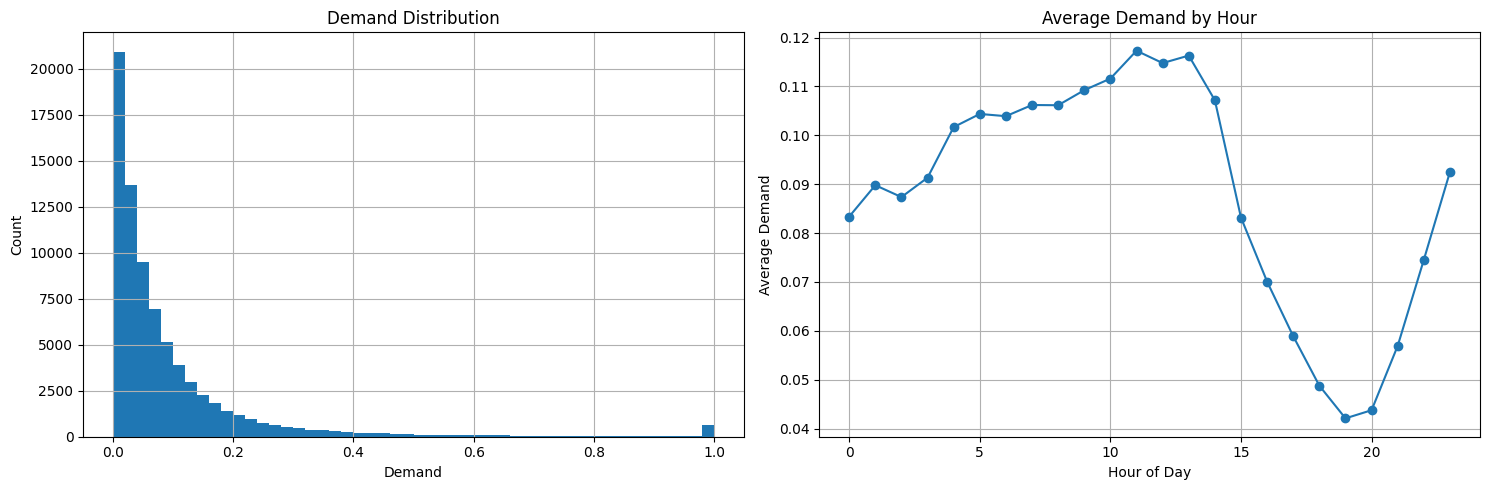

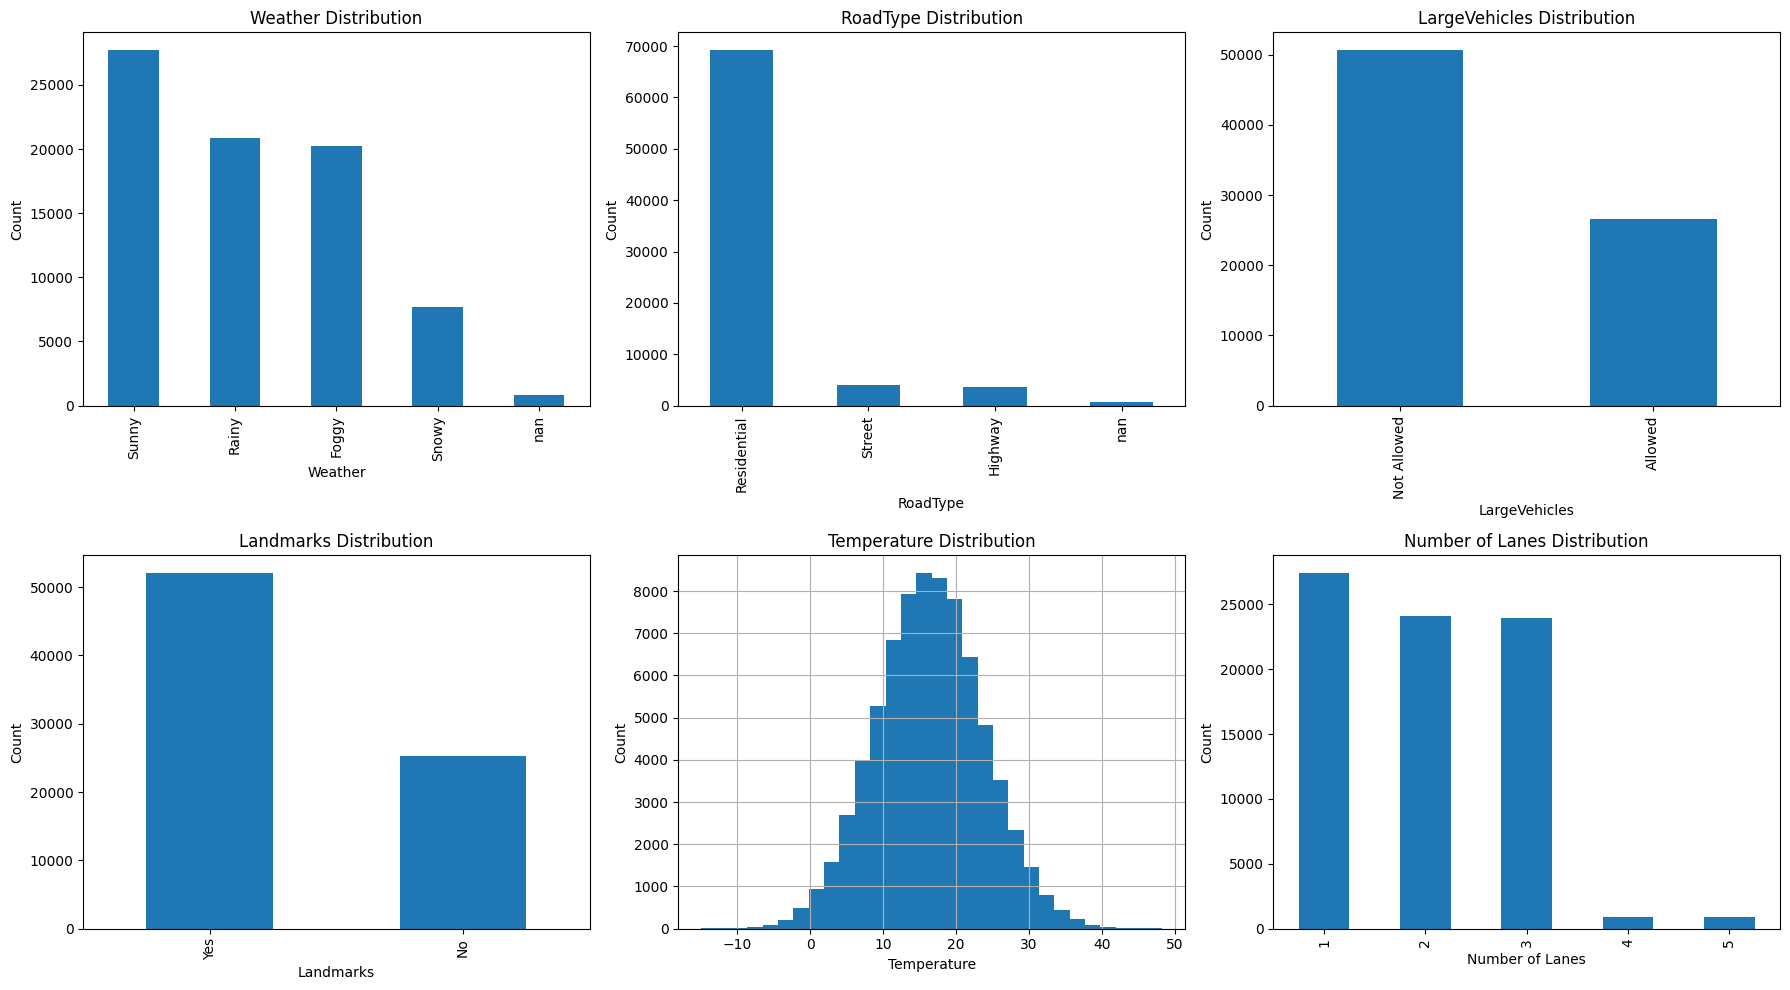

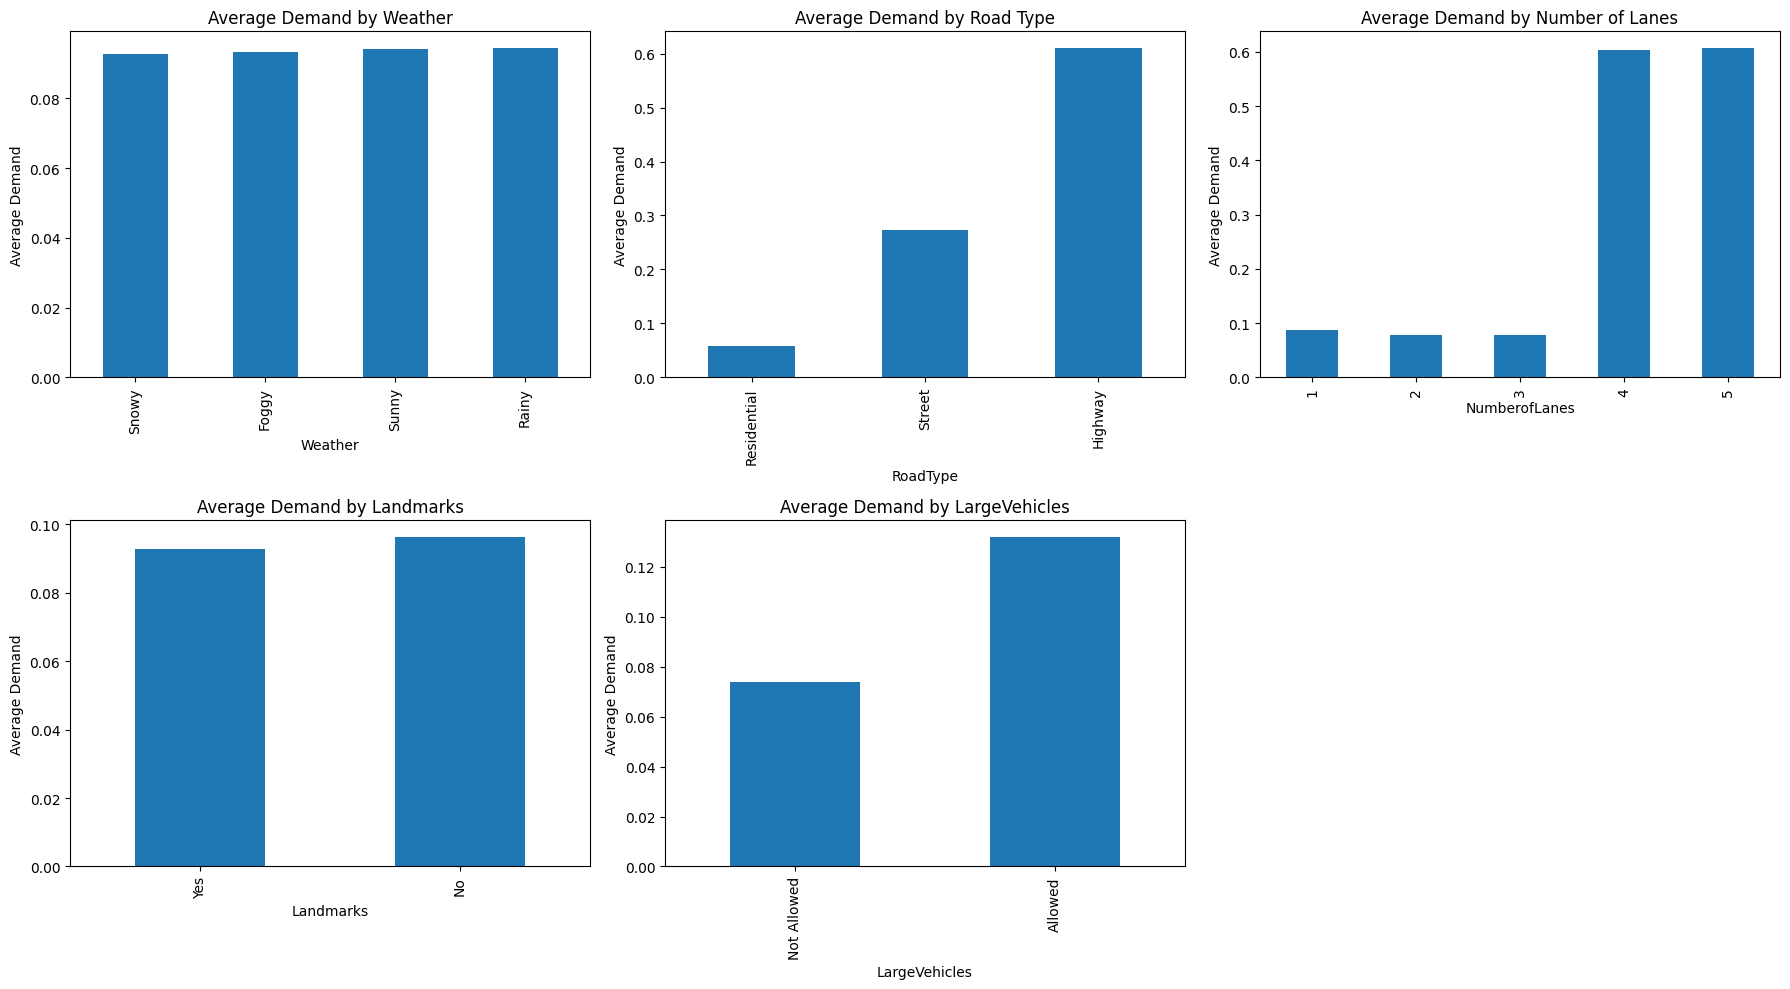


Things to pay attention to:

1. Which Weather has highest demand?
2. Which RoadType has highest demand?
3. Does demand increase with NumberofLanes?
4. Is there a rush hour in the Demand vs Hour plot?
5. How many missing values need handling?
6. Are there obvious outliers in demand or temperature?
7. Which features seem most related to demand?



In [4]:
#  EXPLORATORY DATA ANALYSIS (EDA)

import matplotlib.pyplot as plt

print("Missing Values:")
print(train.isnull().sum())

print("\nDuplicate Rows:")
print(train.duplicated().sum())

# Convert timestamp to datetime
# Assumes timestamps are in HH:MM format

train["timestamp"] = pd.to_datetime(
    train["timestamp"],
    format="%H:%M"
)

## do the same for test set
test["timestamp"] = pd.to_datetime(
    test["timestamp"],
    format="%H:%M"
)

print("\nNumber of Unique Locations:")
print(train["geohash"].nunique())

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Demand histogram
train["demand"].hist(
    bins=50,
    ax=axes[0]
)
axes[0].set_xlabel("Demand")
axes[0].set_ylabel("Count")
axes[0].set_title("Demand Distribution")

# Demand vs Hour
hour_mean = train.groupby(train["timestamp"].dt.hour)["demand"].mean()
hour_mean.plot(
    marker="o",
    ax=axes[1]
)
axes[1].set_title("Average Demand by Hour")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Average Demand")
axes[1].grid(True)
plt.tight_layout()
plt.show()

# FEATURE DISTRIBUTIONS

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Weather
train["Weather"].value_counts(dropna=False).plot(
    kind="bar",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Weather Distribution")
axes[0, 0].set_ylabel("Count")

# RoadType
train["RoadType"].value_counts(dropna=False).plot(
    kind="bar",
    ax=axes[0, 1]
)
axes[0, 1].set_title("RoadType Distribution")
axes[0, 1].set_ylabel("Count")

# LargeVehicles
train["LargeVehicles"].value_counts(dropna=False).plot(
    kind="bar",
    ax=axes[0, 2]
)
axes[0, 2].set_title("LargeVehicles Distribution")
axes[0, 2].set_ylabel("Count")

# Landmarks
train["Landmarks"].value_counts(dropna=False).plot(
    kind="bar",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Landmarks Distribution")
axes[1, 0].set_ylabel("Count")

# Temperature
train["Temperature"].hist(
    bins=30,
    ax=axes[1, 1]
)
axes[1, 1].set_title("Temperature Distribution")
axes[1, 1].set_xlabel("Temperature")
axes[1, 1].set_ylabel("Count")

# Number of Lanes
train["NumberofLanes"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[1, 2]
)
axes[1, 2].set_title("Number of Lanes Distribution")
axes[1, 2].set_xlabel("Number of Lanes")
axes[1, 2].set_ylabel("Count")

plt.tight_layout()
plt.show()

# RELATIONSHIPS WITH DEMAND

weather_demand = train.groupby("Weather")["demand"].mean().sort_values()
road_demand = train.groupby("RoadType")["demand"].mean().sort_values()
lane_demand = train.groupby("NumberofLanes")["demand"].mean()
landmark_demand = train.groupby("Landmarks")["demand"].mean().sort_values()
vehicle_demand = train.groupby("LargeVehicles")["demand"].mean().sort_values()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Weather vs Demand
weather_demand.plot(
    kind="bar",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Average Demand by Weather")
axes[0, 0].set_ylabel("Average Demand")

# RoadType vs Demand
road_demand.plot(
    kind="bar",
    ax=axes[0, 1]
)
axes[0, 1].set_title("Average Demand by Road Type")
axes[0, 1].set_ylabel("Average Demand")

# Number of Lanes vs Demand
lane_demand.plot(
    kind="bar",
    ax=axes[0, 2]
)
axes[0, 2].set_title("Average Demand by Number of Lanes")
axes[0, 2].set_ylabel("Average Demand")

# Landmarks vs Demand
landmark_demand.plot(
    kind="bar",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Average Demand by Landmarks")
axes[1, 0].set_ylabel("Average Demand")

# LargeVehicles vs Demand
vehicle_demand.plot(
    kind="bar",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Average Demand by LargeVehicles")
axes[1, 1].set_ylabel("Average Demand")

# Empty final slot
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

print("""
Things to pay attention to:

1. Which Weather has highest demand?
2. Which RoadType has highest demand?
3. Does demand increase with NumberofLanes?
4. Is there a rush hour in the Demand vs Hour plot?
5. How many missing values need handling?
6. Are there obvious outliers in demand or temperature?
7. Which features seem most related to demand?
""")

# Feature Analysis

In [5]:
# convert landmarks and large vehicles to binary
train["Landmarks"] = (train["Landmarks"] == 1).astype(int)
train["LargeVehicles"] = (train["LargeVehicles"] == 1).astype(int)
## same for test
test["Landmarks"] = (test["Landmarks"] == 1).astype(int)
test["LargeVehicles"] = (test["LargeVehicles"] == 1).astype(int)

In [6]:
## fill missing values
# temp - median 
train["Temperature"].fillna(train["Temperature"].median(), inplace=True)
# weather - mode 
train["Weather"].fillna(train["Weather"].mode()[0], inplace=True)
# roadtype - mode
train["RoadType"].fillna(train["RoadType"].mode()[0], inplace=True)
## do the same for test set
test["Temperature"].fillna(test["Temperature"].median(), inplace=True)
test["Weather"].fillna(test["Weather"].mode()[0], inplace=True)
test["RoadType"].fillna(test["RoadType"].mode()[0], inplace=True)

C:\Users\C.Karthikeshwar\AppData\Local\Temp\ipykernel_23852\2386969340.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train["Temperature"].fillna(train["Temperature"].median(), inplace=True)
C:\Users\C.Karthikeshwar\AppData\Local\Temp\ipykernel_23852\2386969340.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setti

In [7]:
import numpy as np
# create hours sin and cos
train["hour"] = train["timestamp"].dt.hour
train["hour_sin"] = np.sin(2 * np.pi * train["hour"] / 24)
train["hour_cos"] = np.cos(2 * np.pi * train["hour"] / 24)
## same for test
test["hour"] = test["timestamp"].dt.hour
test["hour_sin"] = np.sin(2 * np.pi * test["hour"] / 24)
test["hour_cos"] = np.cos(2 * np.pi * test["hour"] / 24)

In [8]:
# def is peak hour 
# # add hours later
# test["is_peak"] = test["hour"].isin([4,5,6,7,8,9,10,11,12,13,14]).astype(int)
# train["is_peak"] = train["hour"].isin([4,5,6,7,8,9,10,11,12,13,14]).astype(int)
# didn't work so 
# def traffic_period(hour):
#     if hour <= 3:
#         return "night"
#     elif hour <= 14:
#         return "high"
#     elif hour <= 16:
#         return "transition"
#     elif hour <= 21:
#         return "low"
#     else:
#         return "late_evening"

# train["traffic_period"] = train["hour"].apply(traffic_period)
# test["traffic_period"] = test["hour"].apply(traffic_period)
# not working 

In [9]:
# feature 1 - road capacity 
# capacity_score = (road_weight[RoadType]* NumberofLanes* (1 + LargeVehicles_binary)
road_weight = {
    "Residential": 1,
    "Street": 2,
    "Highway": 3
}

train["road_weight"] = train["RoadType"].map(road_weight)
train["capacity_score"] = train["road_weight"] * train["NumberofLanes"] * (1 + train["LargeVehicles"])
## same for test
test["road_weight"] = test["RoadType"].map(road_weight)
test["capacity_score"] = test["road_weight"] * test["NumberofLanes"] * (1 + test["LargeVehicles"])


In [10]:
# feature 2 interaction features
# road type * hour
train["road_hour_interaction"] = train["road_weight"] * train["hour"]
## same for test
test["road_hour_interaction"] = test["road_weight"] * test["hour"]

In [11]:
# feature 3 geohash target encoding 
# replace each geohash with the average demand for that geohash
# for 1249 unique geohashes, this is better than one-hot encoding and captures location-specific demand patterns
# to avoid data leakage (the demand of a geohash influencing its own mean)
# Split train → train_fold + valid_fold
# Compute geohash means only on train_fold
# Map them to both train_fold and valid_fold
from sklearn.model_selection import train_test_split

train_fold, valid_fold = train_test_split(train, test_size=0.2, random_state=42)

geohash_means = train_fold.groupby("geohash")["demand"].mean()
train_fold["geohash_demand"] = train_fold["geohash"].map(geohash_means)
valid_fold["geohash_demand"] = valid_fold["geohash"].map(geohash_means)

## geohash mean for test set
test["geohash_demand"] = test["geohash"].map(geohash_means)

# Setting up data for the model

In [12]:
columns_to_drop = ["Index", "timestamp", "road_weight", "hour", "Landmarks"]

train_fold = train_fold.drop(columns=columns_to_drop)
valid_fold = valid_fold.drop(columns=columns_to_drop)

X_train = train_fold.drop(columns=["demand"])
y_train = train_fold["demand"]

X_valid = valid_fold.drop(columns=["demand"])
y_valid = valid_fold["demand"]

print(X_train.shape)
print(y_train.shape)

print(X_valid.shape)
print(y_valid.shape)

print(X_train.columns.tolist())


(61839, 12)
(61839,)
(15460, 12)
(15460,)
['geohash', 'day', 'RoadType', 'NumberofLanes', 'LargeVehicles', 'Temperature', 'Weather', 'hour_sin', 'hour_cos', 'capacity_score', 'road_hour_interaction', 'geohash_demand']


# Build the baseline model

In [13]:
from catboost import CatBoostRegressor

# tell catboost which coloumns are cateforical
cat_features = [
    X_train.columns.get_loc("geohash"),
    X_train.columns.get_loc("RoadType"),
    X_train.columns.get_loc("Weather"),
    X_train.columns.get_loc("LargeVehicles"),
    # X_train.columns.get_loc("traffic_period") 
]
# create model
model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    verbose=100,
    random_seed=42
)
# train 
model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_valid, y_valid)
)
# predict 
y_pred = model.predict(X_valid)
# evaluate 
from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(y_valid, y_pred)
rmse = mean_squared_error(y_valid, y_pred) ** 0.5

print("R²:", r2)
print("RMSE:", rmse)

# feature importance 
importance = model.get_feature_importance()

for feature, score in zip(X_train.columns, importance):
    print(feature, score)

0:	learn: 0.1360696	test: 0.1360900	best: 0.1360900 (0)	total: 210ms	remaining: 6m 59s
100:	learn: 0.0402239	test: 0.0414157	best: 0.0414157 (100)	total: 7.09s	remaining: 2m 13s
200:	learn: 0.0374978	test: 0.0389537	best: 0.0389537 (200)	total: 14s	remaining: 2m 5s
300:	learn: 0.0359246	test: 0.0376462	best: 0.0376444 (299)	total: 21.1s	remaining: 1m 59s
400:	learn: 0.0349620	test: 0.0368130	best: 0.0368130 (400)	total: 27.5s	remaining: 1m 49s
500:	learn: 0.0342362	test: 0.0362258	best: 0.0362258 (500)	total: 33.8s	remaining: 1m 41s
600:	learn: 0.0336674	test: 0.0357804	best: 0.0357804 (600)	total: 39.9s	remaining: 1m 32s
700:	learn: 0.0331696	test: 0.0354699	best: 0.0354699 (700)	total: 46.6s	remaining: 1m 26s
800:	learn: 0.0326996	test: 0.0351410	best: 0.0351376 (798)	total: 52.8s	remaining: 1m 19s
900:	learn: 0.0322519	test: 0.0348332	best: 0.0348332 (900)	total: 59s	remaining: 1m 11s
1000:	learn: 0.0318841	test: 0.0346148	best: 0.0346148 (1000)	total: 1m 5s	remaining: 1m 5s
1100:	l

In [14]:
# fill missing values with 0
test.fillna(0, inplace=True)

# make predictions on the test data
test_pred = model.predict(test[X_train.columns])

# create a submission dataframe
submission = pd.DataFrame({
    "Index": test["Index"],
    "demand": test_pred
})

# save the submission file
submission.to_csv("submission1.csv", index=False)

print("Submission file created successfully!")
submission.head()

Submission file created successfully!


,Index,demand
0,0,0.040179
1,1,0.029931
2,2,0.026879
3,3,0.030087
4,4,0.059614
